Starting velocity analysis for NGC4303
Shape of data: (897, 901)
 data.shape = (897, 901)
((897, 901), (897, 901)) mask and data
 Закрыто 3 открытых FITS файлов
 Файл сохранен: data/NGC4303/NGC4303_VLT_MUSE_residuals.fits
 Закрыто 3 открытых FITS файлов
 Файл сохранен: data/NGC4303/NGC4303_VLT_MUSE_circ_velocities_map.fits
 Закрыто 3 открытых FITS файлов
 Файл сохранен: data/NGC4303/NGC4303_VLT_MUSE_angle_map.fits
 Закрыто 3 открытых FITS файлов
 Файл сохранен: data/NGC4303/NGC4303_VLT_MUSE_distance_map.fits
 Успешно сохранено 4/4 файлов в data/NGC4303
Analysis completed.
 Закрыто 4 открытых FITS файлов
 Файл сохранен: data/NGC4303/NGC4303_VLT_MUSE_vel_grad_xy.fits
 Файл сохранен: data/NGC4303/NGC4303_VLT_MUSE_vel_grad_xy.fits
Galaxy name: NGC4303
Files saved.
shape of flux (897, 901), grad - (897, 901), (897, 901)
len of flux (1030,), grad - (1030,), (1030,)
Найден открытый HDUList: [<astropy.io.fits.hdu.image.PrimaryHDU object at 0x0000021C1E3F4FB0>]
Сохраняю 6 графиков в pic/NGC4303

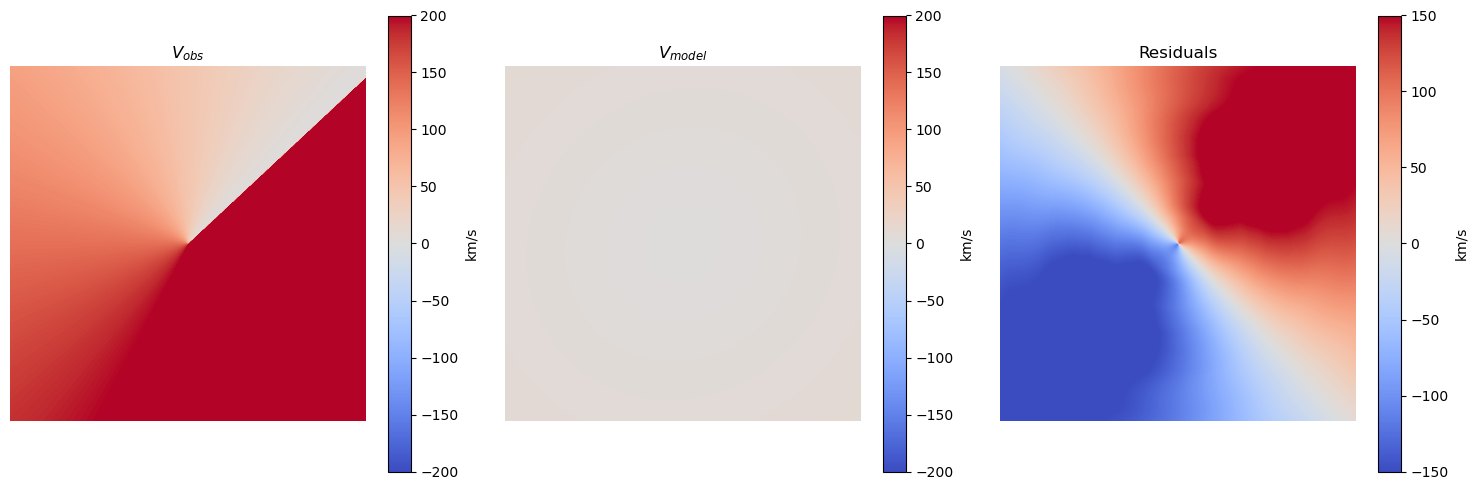

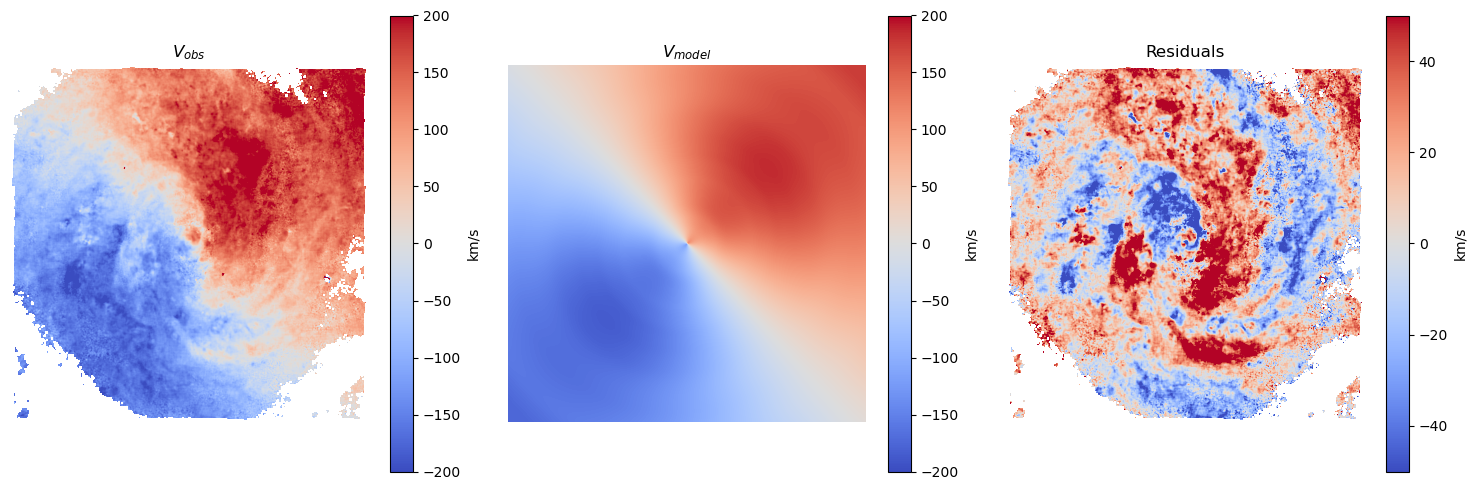

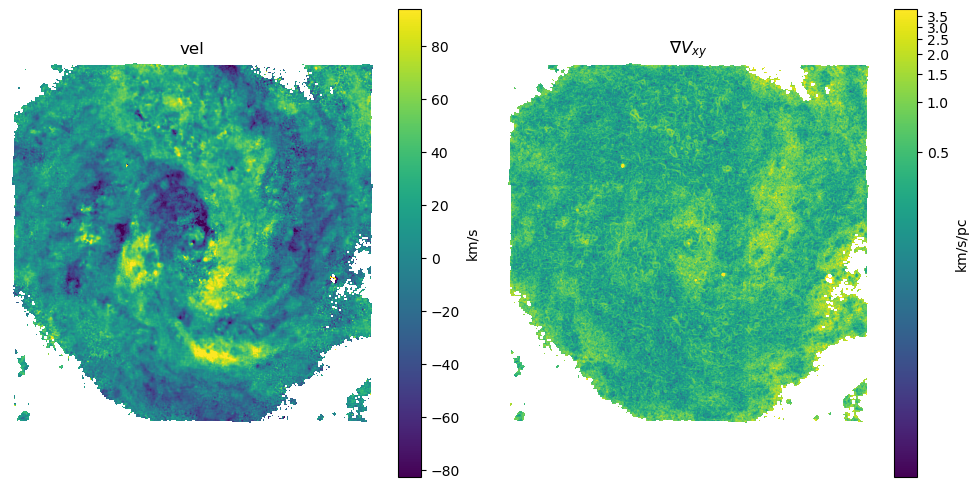

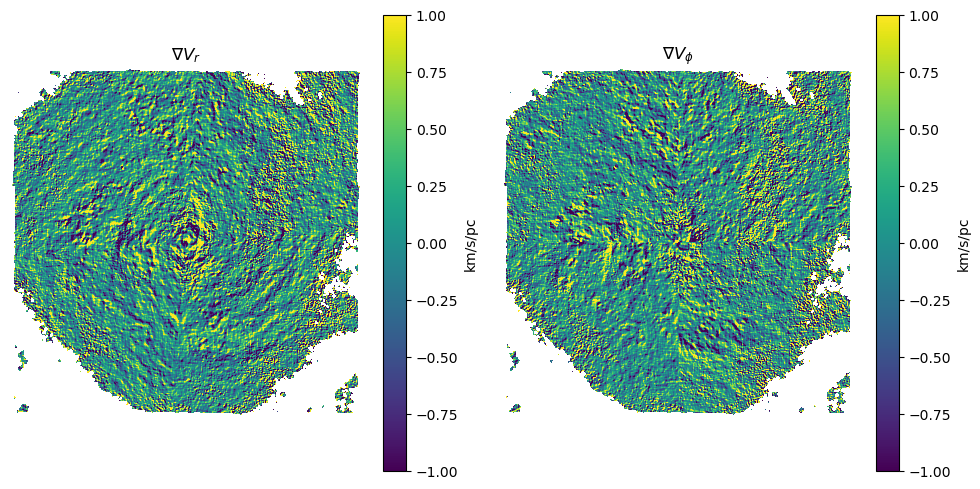

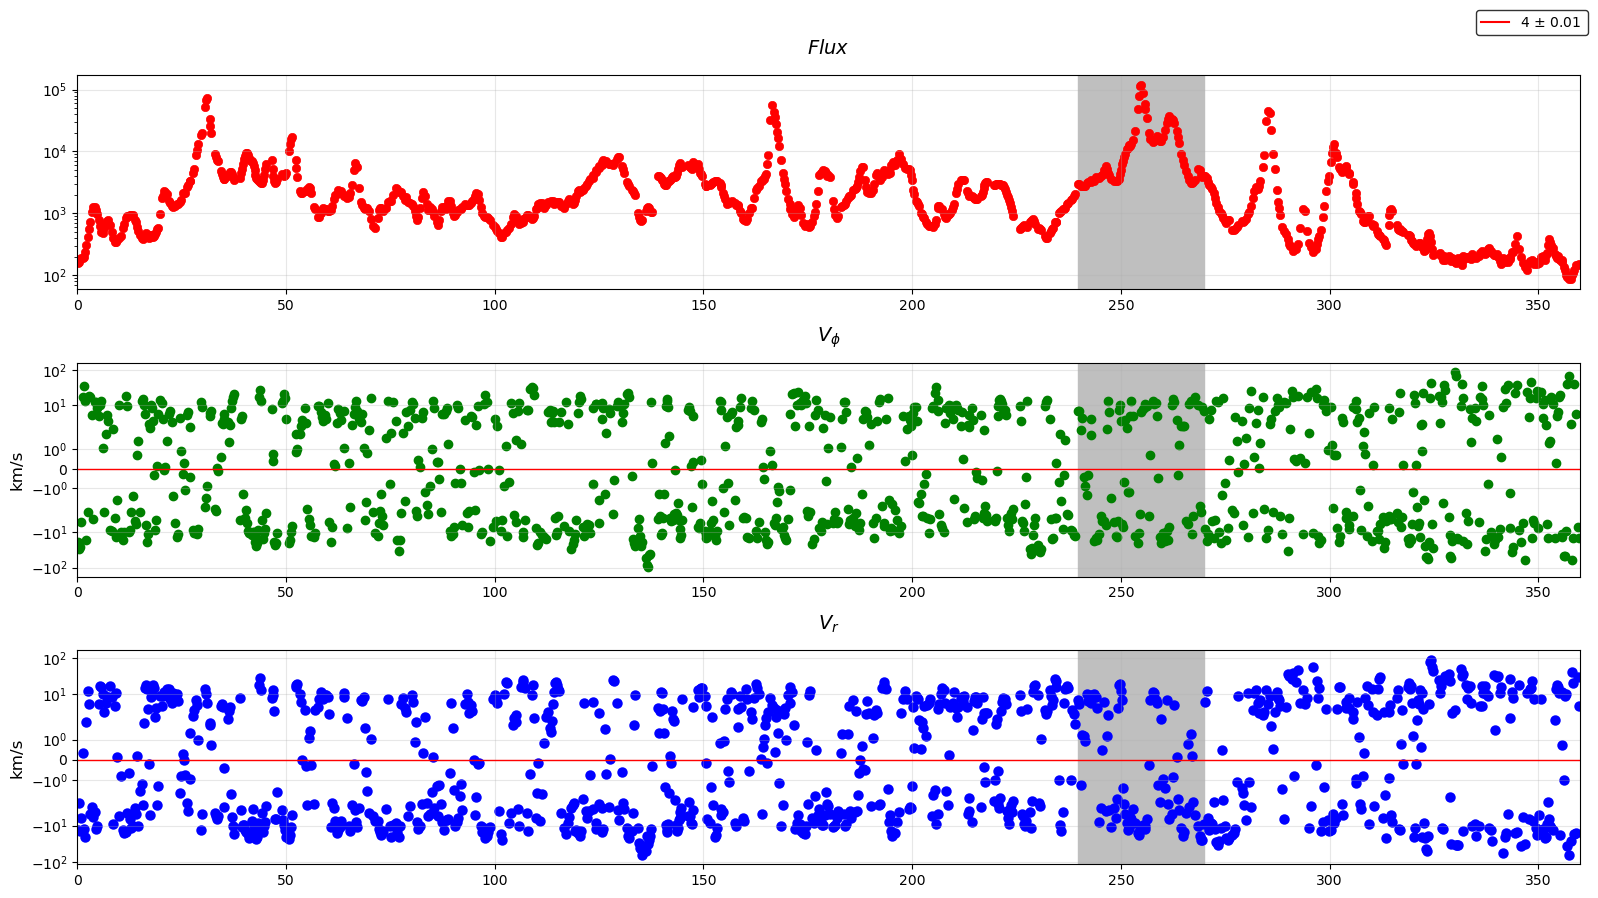

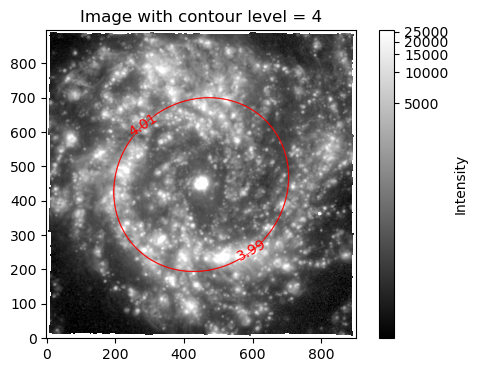

In [177]:
import importlib
import gc
from astropy.io import fits
import numpy as np
# Сначала импортируем модуль
import velocity_analysis
# ПЕРЕЗАГРУЗКА МОДУЛЯ
importlib.reload(velocity_analysis)
from velocity_analysis import run_velocity_analysis, run_gradient_analysis, run_azimuthal_analysis, plot_image_with_contour, save_to_pdf, close_all_fits_files

# Параметры галактики
galaxy_name = "NGC4303"
telescop = "VLT_MUSE"
dist = 17
pa = 317 
incl = 23
shift_vel = 0
r = 4
bound = 0.01
scale_factor = None    # None or int

# Пути к файлам
velocity_file = f"data/input{galaxy_name}/{galaxy_name}_RV.fits"
rad_file = f"data/input{galaxy_name}/{galaxy_name}_r_Ha.npy"
circ_vel_file = f"data/input{galaxy_name}/{galaxy_name}_vel_Ha.npy"
flux_file = f"data/input{galaxy_name}/{galaxy_name}_F_Ha.fit"

# flux_file = f"data/input{galaxy_name}/F_CO.fits"
# sigma_file = f"data/input{galaxy_name}/{galaxy_name}_vel_Ha_err.fits"

@save_to_pdf(f"pic/{galaxy_name}_{telescop}R{r}_{bound}_analysis.pdf")
def run_full_analysis():

    close_all_fits_files()
    # Шаг 1: Анализ скоростей
    resid, model_vel_map, hdu = run_velocity_analysis(
        galaxy_name=galaxy_name,
        telescop=telescop,
        dist=dist,
        pa=pa,
        incl=incl,
        velocity_file=velocity_file,
        # sigma_file=sigma_file,
        rad_file=rad_file,
        smooth=scale_factor,
        circ_vel_file=circ_vel_file,
        flux_file=flux_file,
        shift_vel=shift_vel,
        plot=True,
        save=True
    )

    # Шаг 2: Анализ градиентов
    # Теперь у нас в папке data/{galaxy_name} есть необходимые файлы: 
    # {galaxy_name}_residuals.fits, {galaxy_name}_distance_map.fits, {galaxy_name}_angle_map.fits

    # Формируем пути к сохраненным файлам
    import os
    data_dir = f"data/{galaxy_name}"
    velocity_residuals_file = os.path.join(data_dir, f"{galaxy_name}_{telescop}_residuals.fits")
    distance_map_file = os.path.join(data_dir, f"{galaxy_name}_{telescop}_distance_map.fits")
    angle_map_file = os.path.join(data_dir, f"{galaxy_name}_{telescop}_angle_map.fits")

    grad_xy, grad_r, grad_phi = run_gradient_analysis(
        galaxy_name=galaxy_name,
        telescop=telescop,
        dist=dist,
        velocity_file=velocity_residuals_file,
        distance_file=distance_map_file,
        angle_file=angle_map_file,
        # sigma_file=sigma_file,
        PA = pa,
        plot=True,
        save=True, 
        shift_vel=shift_vel
    )

    # Шаг 3: Азимутальное сканирование
    # Теперь у нас есть градиенты, сохраненные в той же папке
    grad_r_file = os.path.join(data_dir, f"{galaxy_name}_{telescop}_vel_grad_r.fits")
    grad_phi_file = os.path.join(data_dir, f"{galaxy_name}_{telescop}_vel_grad_phi.fits")

    run_azimuthal_analysis(
        galaxy_name=galaxy_name,
        telescop=telescop,
        dist=dist,
        flux_file=flux_file,
        grad_r_file=grad_r_file,
        grad_phi_file=grad_phi_file,
        angle_file=angle_map_file,
        distance_file=distance_map_file,
        R=r,  # пример радиуса
        bound=bound
    )


    plot_image_with_contour(flux_file, distance_map_file, r, bound=bound, percent=99)

    # Принудительный сбор мусора (может помочь)
    gc.collect()

    # Проверка открытых файлов (если нужно)
    for obj in gc.get_objects():
        if isinstance(obj, fits.HDUList):
            print(f"Найден открытый HDUList: {obj}")
            obj.close()

run_full_analysis()


In [49]:

def close_all_fits_files():
    """Принудительно закрывает все открытые FITS файлы"""
    for obj in gc.get_objects():
        if isinstance(obj, fits.HDUList):
            try:
                obj.close()
                print("Закрыт открытый FITS файл")
            except:
                pass

# Вызовите эту функцию перед открытием файла
close_all_fits_files()

Закрыт открытый FITS файл
Закрыт открытый FITS файл
Закрыт открытый FITS файл
Закрыт открытый FITS файл
Закрыт открытый FITS файл


In [ ]:
! fitsheader data/inputNGC1566/NGC1566_sigma_Ha.fits

In [ ]:
import numpy as np

# Открываем файл
data = np.load('data/inputNGC4303/NGC4303_r_Ha.npy')

# Выводим информацию о данных
print("Форма массива:", data.shape)
print("Тип данных:", data.dtype)
print("Размер:", data.size)
print("\nДанные:")
print(data)

In [ ]:
# Принудительный сбор мусора (может помочь)
gc.collect()

# Проверка открытых файлов (если нужно)
for obj in gc.get_objects():
    if isinstance(obj, fits.HDUList):
        print(f"Найден открытый HDUList: {obj}")
        obj.close()

____________________________________________
ZOOM with overlay

d:\vs_code\vel_grad\velocity_gradients\velocity_analysis.py:403: SyntaxWarning: invalid escape sequence '\,'
  


Найдены данные в HDU[0], форма: (1187, 898)
data cut shape = (2, 838, 576)


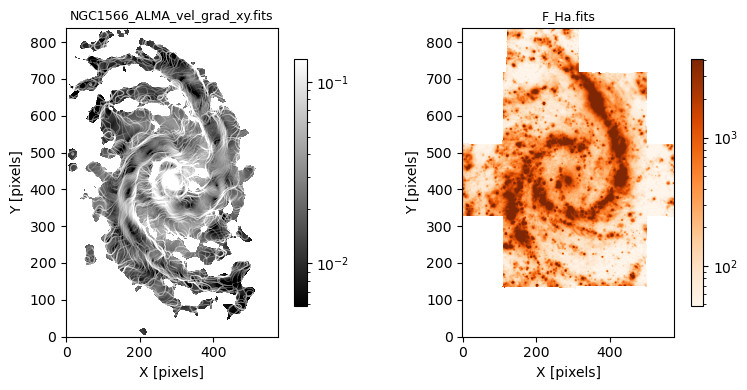

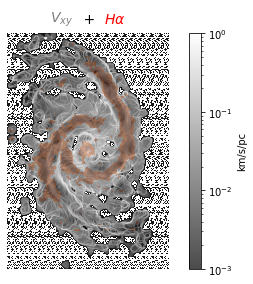

In [160]:
from matplotlib import pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import velocity_analysis
# ПЕРЕЗАГРУЗКА МОДУЛЯ
importlib.reload(velocity_analysis)
from velocity_analysis import overlay_multiple_fits, plot_with_zoom

# Использование:
galaxy_name = "NGC1566"
# for H_alpha
zoom_area1 = [500, 500, 650, 600]
zoom_area2 = [550, 700, 700, 800]
zoom_area3 = [270, 250, 370, 350]
# for CO
zoom_area1_1 = [350, 350, 450, 450]
zoom_area1_2 = [350, 550, 450, 650]
zoom_area1_3 = [150, 250, 250, 350]
zoom_area = None
# Замените на пути к вашим файлам
file_ref = f"data/{galaxy_name}/{galaxy_name}_ALMA_vel_grad_xy.fits"
files = [  f"data/input{galaxy_name}/F_Ha.fits"]
filename = f"pic/{galaxy_name}_grad_CO_F_Ha.pdf"

with PdfPages(filename) as pdf:
# Совмещаем изображения
    overlay_multiple_fits(file_ref, files, zoom=zoom_area, pdf=pdf, percents=[0, 20, 30], alphas=[0.7, 1, 0.9], title=None, galaxy_name=galaxy_name)
    # plot_with_zoom(fits.open(file_ref)[0].data, zoom_area=zoom_area, pdf=pdf)



___________
Dispersion

In [38]:
import numpy as np
import matplotlib.pyplot as plt

def plot_gradient_vs_dispersion(gradient_xy, dispersion, xlabel='Gradient XY, km/s', ylabel='Dispersion, km/s'):
    """
    Строит scatter plot градиента по XY vs дисперсия и возвращает массив,
    где каждый пиксель содержит градиент, если он > дисперсии, иначе NaN
    
    Parameters:
    -----------
    gradient_xy : ndarray
        2D массив градиента по XY
    dispersion : ndarray
        2D массив дисперсии
    xlabel, ylabel : str
        Подписи осей
        
    Returns:
    --------
    gradient_where_gt : ndarray
        2D массив той же формы, что и gradient_xy, где:
        - значение = gradient_xy, если gradient_xy > dispersion
        - значение = np.nan в противном случае
    grad_clean : ndarray
        1D массив очищенных значений градиента (для анализа)
    disp_clean : ndarray
        1D массив очищенных значений дисперсии (для анализа)
    """
    
    # Создаем копии для сохранения формы
    grad_2d = gradient_xy.copy()
    disp_2d = dispersion.copy()
    
    # Создаем маску для корректных значений
    valid_mask = (np.isfinite(grad_2d) & 
                  np.isfinite(disp_2d) & 
                  (disp_2d <= 500))
    
    # Создаем результирующий массив, инициализированный NaN
    gradient_where_gt = np.full_like(grad_2d, np.nan, dtype=np.float32)
    
    # Применяем условие только к корректным пикселям
    condition_mask = valid_mask & (grad_2d > disp_2d)
    gradient_where_gt[condition_mask] = grad_2d[condition_mask]
    
    # Для scatter plot преобразуем в 1D
    grad_flat = grad_2d.flatten()
    disp_flat = disp_2d.flatten()
    
    # Убираем NaN и бесконечные значения для статистики
    mask = (np.isfinite(grad_flat) & 
            np.isfinite(disp_flat) & 
            (disp_flat <= 500))
    grad_clean = grad_flat[mask]
    disp_clean = disp_flat[mask]
    
    # Статистика
    print(f"Всего точек: {len(grad_clean)}")
    print(f"Gradient range: [{np.min(grad_clean):.3f}, {np.max(grad_clean):.3f}]")
    print(f"Dispersion range: [{np.min(disp_clean):.3f}, {np.max(disp_clean):.3f}]")
    
    # Подсчет пикселей, где градиент > дисперсии
    mask_gr_gt_dis = grad_clean > disp_clean
    count_gr_gt_dis = np.sum(mask_gr_gt_dis)
    total_pixels = len(grad_clean)
    fraction_gr_gt_dis = count_gr_gt_dis / total_pixels

    print(f"Пикселей где градиент > дисперсии: {count_gr_gt_dis:,} из {total_pixels:,}")
    print(f"Доля: {fraction_gr_gt_dis:.3f} ({fraction_gr_gt_dis*100:.1f}%)")
    
    # Дополнительная статистика по 2D массиву
    valid_pixels_2d = np.sum(valid_mask)
    gt_pixels_2d = np.sum(condition_mask)
    print(f"В 2D массиве: {gt_pixels_2d:,} из {valid_pixels_2d:,} пикселей удовлетворяют условию")
    print(f"Размер возвращаемого массива: {gradient_where_gt.shape}")
    print(f"Количество не-NaN значений в результате: {np.sum(~np.isnan(gradient_where_gt)):,}")
    
    # Создаем scatter plot
    plt.figure(figsize=(8, 6))
    
    # Простой scatter
    plt.scatter(grad_clean, disp_clean, alpha=0.6, s=1, c='blue')
    
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.ylim(0, 110)
    plt.xlim(0, 110)
    plt.title(f'Scatter: {xlabel} vs {ylabel}\nДоля grad>disp: {fraction_gr_gt_dis*100:.1f}%')
    plt.grid(True, alpha=0.3)
    
    # Линия y=x
    plt.plot([0, 100], [0, 100], color='r', linewidth=2, label='y=x')
    
    # Отмечаем точку средних
    plt.scatter([np.mean(grad_clean)], [np.mean(disp_clean)], 
                color='red', s=100, marker='x', linewidths=2, 
                label=f'Mean: ({np.mean(grad_clean):.1f}, {np.mean(disp_clean):.1f})')
    
    plt.legend()
    plt.tight_layout()
    plt.show()

    return gradient_where_gt, grad_clean, disp_clean


# Пример использования:
# gradient_where_gt, grad_clean, disp_clean = plot_gradient_vs_dispersion(gradient_array, dispersion_array)

In [5]:


def read_gradient_dispersion_fits(gradient_file, dispersion_file, hdu_index=0):
    """
    Читает градиент и дисперсию из FITS-файлов
    
    Parameters:
    -----------
    gradient_file : str
        Путь к FITS-файлу с градиентом
    dispersion_file : str
        Путь к FITS-файлу с дисперсией
    hdu_index : int, optional
        Индекс HDU для чтения (по умолчанию 0)
    
    Returns:
    --------
    gradient_data : ndarray
        Массив градиента
    dispersion_data : ndarray
        Массив дисперсии
    """
    
    print(f"Чтение градиента из: {gradient_file}")
    with fits.open(gradient_file) as hdul:
        gradient_data = hdul[hdu_index].data
        gradient_header = hdul[hdu_index].header
        print(f"  Размер: {gradient_data.shape}")
        print(f"  Тип данных: {gradient_data.dtype}")
    
    print(f"Чтение дисперсии из: {dispersion_file}")
    with fits.open(dispersion_file) as hdul:
        dispersion_data = hdul[hdu_index].data
        dispersion_header = hdul[hdu_index].header
        print(f"  Размер: {dispersion_data.shape}")
        print(f"  Тип данных: {dispersion_data.dtype}")
    
    # Проверяем совпадение размеров
    if gradient_data.shape != dispersion_data.shape:
        print(f"⚠️ ВНИМАНИЕ: Размеры не совпадают!")
        print(f"  Градиент: {gradient_data.shape}")
        print(f"  Дисперсия: {dispersion_data.shape}")
        
        # Автоматическое обрезание до минимального размера
        min_shape = (min(gradient_data.shape[0], dispersion_data.shape[0]),
                    min(gradient_data.shape[1], dispersion_data.shape[1]))
        
        gradient_data = gradient_data[:min_shape[0], :min_shape[1]]
        dispersion_data = dispersion_data[:min_shape[0], :min_shape[1]]
        print(f"  Обрезано до: {min_shape}")
    
    return gradient_data, dispersion_data, gradient_header, dispersion_header

Всего точек: 617601
Gradient range: [0.021, 2570.926]
Dispersion range: [0.040, 86.521]
Пикселей где градиент > дисперсии: 601,786 из 617,601
Доля: 0.974 (97.4%)
В 2D массиве: 601,786 из 617,601 пикселей удовлетворяют условию
Размер возвращаемого массива: (1187, 898)
Количество не-NaN значений в результате: 601,786


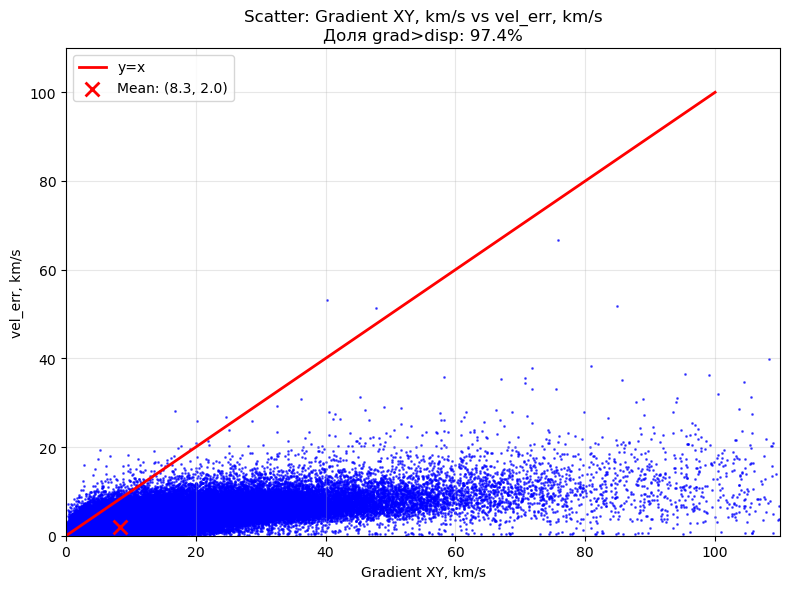

In [ ]:
grad, sigma, _, h = read_gradient_dispersion_fits("data/NGC1566/NGC1566_VLT_MUSE_vel_grad_xy.fits", "data/inputNGC1566/NGC1566_vel_Ha_err.fits")
grad_, _, _ = plot_gradient_vs_dispersion(grad*20, sigma, ylabel="vel_err, km/s")

In [42]:
# mask = grad_ > sigma_
fraction = np.sum(grad_) / grad_.size
print(f"Доля grad > sigma: {fraction:.3f} ({fraction*100:.1f}%)")

# Или в одну строку
# fraction = np.mean(grad_ > )  # True=1, False=0, mean = доля True
print(f"Доля grad > sigma: {fraction:.3f}")

Доля grad > sigma: nan (nan%)
Доля grad > sigma: nan


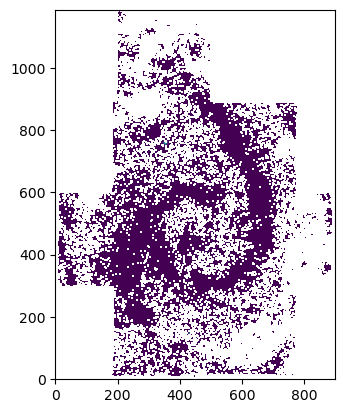

In [ ]:

plt.imshow(grad_, origin="lower")


In [2]:
def analyze_high_dispersion_regions(dispersion_data, gradient_data, flux_data=None, threshold=100):
    """
    Анализирует регионы с дисперсией > 100 км/с
    """
    
    dispersion_flat = dispersion_data.flatten()
    gradient_flat = gradient_data.flatten()
    
    # Маски для разных уровней дисперсии
    mask_low = dispersion_flat <= 80
    mask_medium = (dispersion_flat > 80) & (dispersion_flat <= 150)
    mask_high = dispersion_flat > 150
    mask_very_high = dispersion_flat > 200
    
    mask_finite = np.isfinite(dispersion_flat) & np.isfinite(gradient_flat)
    
    print("=== АНАЛИЗ ОБЛАСТЕЙ С ВЫСОКОЙ ДИСПЕРСИЕЙ ===")
    print(f"Всего пикселей: {np.sum(mask_finite):,}")
    print(f"Дисперсия ≤ 80 км/с: {np.sum(mask_low & mask_finite):,} ({np.sum(mask_low & mask_finite)/np.sum(mask_finite)*100:.1f}%)")
    print(f"Дисперсия 80-150 км/с: {np.sum(mask_medium & mask_finite):,} ({np.sum(mask_medium & mask_finite)/np.sum(mask_finite)*100:.1f}%)")
    print(f"Дисперсия > 150 км/с: {np.sum(mask_high & mask_finite):,} ({np.sum(mask_high & mask_finite)/np.sum(mask_finite)*100:.1f}%)")
    print(f"Дисперсия > 200 км/с: {np.sum(mask_very_high & mask_finite):,} ({np.sum(mask_very_high & mask_finite)/np.sum(mask_finite)*100:.1f}%)")
    
    # Визуализация
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # 1. Распределение по дисперсии
    axes[0,0].hist(dispersion_flat[mask_finite], bins=50, alpha=0.7)
    axes[0,0].axvline(100, color='red', linestyle='--', label='100 км/с')
    axes[0,0].axvline(150, color='orange', linestyle='--', label='150 км/с')
    axes[0,0].axvline(200, color='red', linestyle='--', label='200 км/с')
    axes[0,0].axvline(np.mean(dispersion_flat[mask_finite]), color='green', linestyle='-', label=f'Mean {np.mean(dispersion_flat[mask_finite])} км/с')
    # plt.axhline(np.mean(disp_clean), color='green', linestyle='--', alpha=0.8, label=f'Mean Y: {np.mean(disp_clean):.3f}')

    axes[0,0].set_xlabel('Дисперсия (км/с)')
    axes[0,0].set_ylabel('Количество пикселей')
    axes[0,0].set_title('Распределение дисперсии')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # 2. Scatter plot с цветовой кодировкой
    colors = ['green', 'orange', 'red']
    labels = [f'{np.sum(mask_low & mask_finite)} pix (≤80 km/s)', f'{np.sum(mask_medium & mask_finite)} pix (80-150 km/s)', f'{np.sum(mask_high & mask_finite & mask_very_high)} pix (>150 km/s)']
    masks = [mask_low, mask_medium, mask_high]
    
    for i, (mask_level, color, label) in enumerate(zip(masks, colors, labels)):
        current_mask = mask_level & mask_finite
        axes[0,1].scatter(gradient_flat[current_mask], dispersion_flat[current_mask], 
                         alpha=0.6, s=1, color=color, label=label)
    
    axes[0,1].set_xlabel('Градиент скорости')
    axes[0,1].set_ylabel('Дисперсия (км/с)')
    axes[0,1].set_title('Дисперсия vs Градиент')
    axes[0,1].legend(markerscale=3)
    axes[0,1].grid(True, alpha=0.3)
    
    # 3. Процент высокодисперсных регионов
    categories = ['≤80 км/с', '80-150 км/с', '>150 км/с']
    counts = [np.sum(mask_low & mask_finite), np.sum(mask_medium & mask_finite), np.sum(mask_high & mask_finite)]
    
    axes[0,2].pie(counts, labels=categories, colors=colors, autopct='%1.1f%%')
    axes[0,2].set_title('Распределение по уровням дисперсии')
    
    # 4. Статистика по градиентам для разных уровней дисперсии
    dispersion_levels = [
        ('Низкая (≤80)', mask_low),
        ('Средняя (80-150)', mask_medium), 
        ('Высокая (>150)', mask_high)
    ]
    
    grad_means = []
    grad_stds = []
    
    for label, mask in dispersion_levels:
        current_mask = mask & mask_finite
        grad_means.append(np.mean(gradient_flat[current_mask]))
        grad_stds.append(np.std(gradient_flat[current_mask]))
    
    x_pos = np.arange(len(dispersion_levels))
    axes[1,0].bar(x_pos, grad_means, yerr=grad_stds, capsize=5, color=colors, alpha=0.7)
    axes[1,0].set_xticks(x_pos)
    axes[1,0].set_xticklabels([label for label, _ in dispersion_levels])
    axes[1,0].set_ylabel('Средний градиент')
    axes[1,0].set_title('Градиенты по уровням дисперсии')
    axes[1,0].grid(True, alpha=0.3)
    
    # 5. Пространственное распределение (если есть координаты)
    if flux_data is not None:
        flux_flat = flux_data.flatten()
        mask_flux_finite = mask_finite & np.isfinite(flux_flat)
        
        axes[1,1].scatter(flux_flat[mask_flux_finite], dispersion_flat[mask_flux_finite], 
                         alpha=0.3, s=1, c=dispersion_flat[mask_flux_finite], cmap='viridis')
        axes[1,1].set_xlabel('Поток Hα')
        axes[1,1].set_ylabel('Дисперсия (км/с)')
        axes[1,1].set_title('Дисперсия vs Поток')
        axes[1,1].set_yscale('log')
        axes[1,1].set_xscale('log')
        axes[1,1].grid(True, alpha=0.3)
    
    # 6. Кумулятивное распределение
    sorted_disp = np.sort(dispersion_flat[mask_finite])
    y_cumulative = np.arange(1, len(sorted_disp)+1) / len(sorted_disp)
    axes[1,2].plot(sorted_disp, y_cumulative * 100, linewidth=2)
    axes[1,2].axvline(100, color='red', linestyle='--', alpha=0.7, label='100 км/с')
    axes[1,2].axvline(150, color='orange', linestyle='--', alpha=0.7, label='150 км/с')
    axes[1,2].set_xlabel('Дисперсия (км/с)')
    axes[1,2].set_ylabel('Кумулятивный процент (%)')
    axes[1,2].set_title('Кумулятивное распределение')
    axes[1,2].legend()
    axes[1,2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return {
        'low_disp': (gradient_flat[mask_low & mask_finite], dispersion_flat[mask_low & mask_finite]),
        'medium_disp': (gradient_flat[mask_medium & mask_finite], dispersion_flat[mask_medium & mask_finite]),
        'high_disp': (gradient_flat[mask_high & mask_finite], dispersion_flat[mask_high & mask_finite])
    }

In [ ]:
with fits.open(flux_file) as hdul:
    # Показываем информацию о всех HDU
    hdul.info()
    
    # Берем данные из первого HDU с данными
    for i, hdu in enumerate(hdul):
        if hdu.data is not None:
            print(f"HDU[{i}]: форма {hdu.data.shape}")
            flux_data = hdu.data
            flux_header = hdu.header
            break

In [ ]:
analyze_high_dispersion_regions(sigma, grad*20, flux_data, max_percentile=99)

In [ ]:
def analyze_high_dispersion_regions(dispersion_data, gradient_data, flux_data=None, threshold=100, max_percentile=90):
    """
    Анализирует регионы с дисперсией > 100 км/с
    с ограничением максимальных значений по процентилю
    
    Parameters:
    -----------
    dispersion_data : ndarray
        Массив дисперсии
    gradient_data : ndarray
        Массив градиента
    flux_data : ndarray, optional
        Массив потока
    threshold : int
        Порог для определения "высокой" дисперсии
    max_percentile : float
        Максимальный процентиль для отображения (например, 90 для 90%)
    """
    
    dispersion_flat = dispersion_data.flatten()
    gradient_flat = gradient_data.flatten()
    
    # Определяем максимальное значение для отображения по процентилю
    dispersion_max_display = np.percentile(dispersion_flat[np.isfinite(dispersion_flat)], max_percentile)
    
    print(f"=== АНАЛИЗ ОБЛАСТЕЙ С ВЫСОКОЙ ДИСПЕРСИЕЙ ===")
    print(f"Ограничение по процентилю: показываем значения ≤ {max_percentile}% = {dispersion_max_display:.1f} км/с")
    
    # Маски для разных уровней дисперсии
    mask_low = dispersion_flat <= 80
    mask_medium = (dispersion_flat > 80) & (dispersion_flat <= 150)
    mask_high = dispersion_flat > 150
    mask_very_high = dispersion_flat > 200
    
    # Маска для отображения (исключаем верхние значения)
    mask_display = dispersion_flat <= dispersion_max_display
    
    mask_finite = np.isfinite(dispersion_flat) & np.isfinite(gradient_flat)
    mask_finite_display = mask_finite & mask_display
    
    print(f"Всего пикселей: {np.sum(mask_finite):,}")
    print(f"Показываем: {np.sum(mask_finite_display):,} ({np.sum(mask_finite_display)/np.sum(mask_finite)*100:.1f}%)")
    print(f"Дисперсия ≤ 80 км/с: {np.sum(mask_low & mask_finite):,} ({np.sum(mask_low & mask_finite)/np.sum(mask_finite)*100:.1f}%)")
    print(f"Дисперсия 80-150 км/с: {np.sum(mask_medium & mask_finite):,} ({np.sum(mask_medium & mask_finite)/np.sum(mask_finite)*100:.1f}%)")
    print(f"Дисперсия > 150 км/с: {np.sum(mask_high & mask_finite):,} ({np.sum(mask_high & mask_finite)/np.sum(mask_finite)*100:.1f}%)")
    print(f"Дисперсия > 200 км/с: {np.sum(mask_very_high & mask_finite):,} ({np.sum(mask_very_high & mask_finite)/np.sum(mask_finite)*100:.1f}%)")
    
    # Визуализация
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # 1. Распределение по дисперсии (с ограничением)
    ax1 = axes[0, 0]
    
    # Без ограничения (прозрачный)
    bins_all = np.linspace(0, np.max(dispersion_flat[mask_finite]), 61)
    ax1.hist(dispersion_flat[mask_finite], bins=bins_all, alpha=0.3, 
             color='gray', label=f'Все данные (n={np.sum(mask_finite):,})', density=True)
    
    # С ограничением по процентилю
    bins_display = np.linspace(0, dispersion_max_display, 41)
    ax1.hist(dispersion_flat[mask_finite_display], bins=bins_display, alpha=0.7, 
             color='blue', label=f'≤{max_percentile}% ({dispersion_max_display:.0f} км/с)', density=True)
    
    ax1.axvline(100, color='red', linestyle='--', alpha=0.7, label='100 км/с')
    ax1.axvline(150, color='orange', linestyle='--', alpha=0.7, label='150 км/с')
    ax1.axvline(dispersion_max_display, color='purple', linestyle='-', alpha=0.8, 
                label=f'{max_percentile}% = {dispersion_max_display:.0f} км/с')
    ax1.axvline(np.mean(dispersion_flat[mask_finite]), color='green', linestyle='-', 
                alpha=0.7, label=f'Mean: {np.mean(dispersion_flat[mask_finite]):.1f} км/с')
    
    ax1.set_xlabel('Дисперсия (км/с)')
    ax1.set_ylabel('Плотность')
    ax1.set_title(f'Распределение дисперсии\n(показываем ≤ {max_percentile}%)')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, dispersion_max_display * 1.1)
    
    # 2. Scatter plot с цветовой кодировкой (только ≤ процентилю)
    ax2 = axes[0, 1]
    
    colors = ['green', 'orange', 'red']
    labels = [
        f'≤80 км/с (n={np.sum(mask_low & mask_finite_display):,})',
        f'80-150 км/с (n={np.sum(mask_medium & mask_finite_display):,})', 
        f'>150 км/с (n={np.sum(mask_high & mask_finite_display):,})'
    ]
    masks = [mask_low, mask_medium, mask_high]
    ax2.scatter(gradient_flat[mask_finite_display], dispersion_flat[mask_finite_display], 
                       alpha=0.6, s=1)
    # for i, (mask_level, color, label) in enumerate(zip(masks, colors, labels)):
    #     current_mask = mask_level & mask_finite_display
    #     if np.sum(current_mask) > 0:
    #         ax2.scatter(gradient_flat[current_mask], dispersion_flat[current_mask], 
    #                    alpha=0.6, s=1, color=color, label=label)
    ax2.plot([20, 100], [20, 100], color='crimson')
    ax2.set_xlabel('Градиент скорости')
    ax2.set_ylabel('Дисперсия (км/с)')
    ax2.set_title(f'Дисперсия vs Градиент (≤ {max_percentile}%)')
    ax2.legend(markerscale=3, fontsize=9)
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(20, dispersion_max_display * 1.05)
    ax2.set_xlim(20, dispersion_max_display * 1.05)
    
    # 3. Процент высокодисперсных регионов (из всех данных)
    ax3 = axes[0, 2]
    categories = ['≤80 км/с', '80-150 км/с', '>150 км/с']
    counts = [np.sum(mask_low & mask_finite), np.sum(mask_medium & mask_finite), np.sum(mask_high & mask_finite)]
    
    ax3.pie(counts, labels=categories, colors=colors, autopct='%1.1f%%')
    ax3.set_title(f'Распределение по уровням дисперсии\n(n={np.sum(mask_finite):,})')
    
    # 4. Статистика по градиентам для разных уровней дисперсии
    ax4 = axes[1, 0]
    
    dispersion_levels = [
        (f'Низкая\n(≤80 км/с)', mask_low),
        (f'Средняя\n(80-150 км/с)', mask_medium), 
        (f'Высокая\n(>150 км/с)', mask_high)
    ]
    
    grad_means = []
    grad_stds = []
    
    for label, mask in dispersion_levels:
        current_mask = mask & mask_finite
        grad_means.append(np.mean(gradient_flat[current_mask]))
        grad_stds.append(np.std(gradient_flat[current_mask]))
    
    x_pos = np.arange(len(dispersion_levels))
    bars = ax4.bar(x_pos, grad_means, yerr=grad_stds, capsize=5, color=colors, alpha=0.7)
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels([label for label, _ in dispersion_levels])
    ax4.set_ylabel('Средний градиент')
    ax4.set_title('Градиенты по уровням дисперсии')
    ax4.grid(True, alpha=0.3)
    
    # Добавляем значения на столбцы
    for i, (bar, mean_val) in enumerate(zip(bars, grad_means)):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{mean_val:.3f}', ha='center', va='bottom', fontsize=9)
    
    # 5. Пространственное распределение (если есть данные потока)
    ax5 = axes[1, 1]
    
    if flux_data is not None:
        flux_flat = flux_data.flatten()
        mask_flux_finite = mask_finite_display & np.isfinite(flux_flat)
        
        if np.sum(mask_flux_finite) > 0:
            scatter = ax5.scatter(flux_flat[mask_flux_finite], dispersion_flat[mask_flux_finite], 
                                 alpha=0.3, s=1, c=dispersion_flat[mask_flux_finite], cmap='viridis')
            ax5.set_xlabel('Поток Hα')
            ax5.set_ylabel('Дисперсия (км/с)')
            ax5.set_title(f'Дисперсия vs Поток (≤ {max_percentile}%)')
            ax5.set_yscale('log')
            ax5.set_xscale('log')
            ax5.grid(True, alpha=0.3)
            plt.colorbar(scatter, ax=ax5, label='Дисперсия (км/с)')
            ax5.set_ylim(10, dispersion_max_display * 1.1)
    else:
        ax5.text(0.5, 0.5, 'Нет данных потока', ha='center', va='center', 
                transform=ax5.transAxes, fontsize=12)
        ax5.set_title('Дисперсия vs Поток')
    
    # 6. Кумулятивное распределение (с ограничением и без)
    ax6 = axes[1, 2]
    
    # Все данные
    sorted_disp_all = np.sort(dispersion_flat[mask_finite])
    y_cumulative_all = np.arange(1, len(sorted_disp_all)+1) / len(sorted_disp_all)
    
    # Только до процентиля
    mask_up_to_percentile = dispersion_flat[mask_finite] <= dispersion_max_display
    sorted_disp_filtered = np.sort(dispersion_flat[mask_finite][mask_up_to_percentile])
    y_cumulative_filtered = np.arange(1, len(sorted_disp_filtered)+1) / len(sorted_disp_all)
    
    # Рисуем обе кривые
    ax6.plot(sorted_disp_all, y_cumulative_all * 100, linewidth=2, color='gray', 
             alpha=0.5, label='Все данные')
    ax6.plot(sorted_disp_filtered, y_cumulative_filtered * 100, linewidth=2, 
             color='blue', label=f'≤ {max_percentile}%')
    
    ax6.axvline(100, color='red', linestyle='--', alpha=0.7, label='100 км/с')
    ax6.axvline(150, color='orange', linestyle='--', alpha=0.7, label='150 км/с')
    ax6.axvline(dispersion_max_display, color='purple', linestyle='-', alpha=0.8, 
                label=f'{max_percentile}% = {dispersion_max_display:.0f} км/с')
    
    # Добавляем аннотации для процентилей
    percentiles_to_show = [10, 25, 50, 75, 90, 95]
    for p in percentiles_to_show:
        p_value = np.percentile(dispersion_flat[mask_finite], p)
        ax6.axvline(p_value, color='gray', linestyle=':', alpha=0.3)
        if p <= max_percentile:
            ax6.text(p_value, 5, f'{p}%', rotation=90, va='bottom', ha='right', 
                    fontsize=8, alpha=0.7)
    
    ax6.set_xlabel('Дисперсия (км/с)')
    ax6.set_ylabel('Кумулятивный процент (%)')
    ax6.set_title('Кумулятивное распределение')
    ax6.legend(fontsize=9)
    ax6.grid(True, alpha=0.3)
    ax6.set_xlim(0, dispersion_max_display * 1.1)
    
    plt.tight_layout()
    plt.show()
    
    # Вывод статистики процентилей
    print(f"\nСтатистика процентилей дисперсии:")
    percentiles = [10, 25, 50, 75, 90, 95, 99]
    for p in percentiles:
        p_value = np.percentile(dispersion_flat[mask_finite], p)
        print(f"  {p}%: {p_value:.1f} км/с")
    
    return {
        'low_disp': (gradient_flat[mask_low & mask_finite], dispersion_flat[mask_low & mask_finite]),
        'medium_disp': (gradient_flat[mask_medium & mask_finite], dispersion_flat[mask_medium & mask_finite]),
        'high_disp': (gradient_flat[mask_high & mask_finite], dispersion_flat[mask_high & mask_finite]),
        'dispersion_max_display': dispersion_max_display,
        'percentile_stats': {p: np.percentile(dispersion_flat[mask_finite], p) for p in percentiles}
    }

______________________________________________________________________________________________
SUPERNOVAe

In [ ]:
import importlib
# Сначала импортируем модуль
import velocity_analysis
# ПЕРЕЗАГРУЗКА МОДУЛЯ
importlib.reload(velocity_analysis)
from velocity_analysis import plot_supernovae_on_image, plot_supernovae_on_image_zoom


# Пример использования:
if __name__ == "__main__":
    
    # Затем основную функцию
    plot_supernovae_on_image(
        fits_file='data/NGC1566/NGC1566_ALMA_vel_grad_xy.fits',
        sn_file='data/inputNGC1566/SN.txt',
        output_file="pic/trash/supernovae_map_ALMA.png"
    )

In [ ]:
# Пример использования с зумом:
if __name__ == "__main__":
    plot_supernovae_on_image_zoom(
        fits_file='data/NGC1566/NGC1566_VLT_MUSE_vel_grad_xy.fits',
        sn_file='data/inputNGC1566/SN.txt',
        output_file="pic/trash/supernovae_map.png",
        zoom_size=200  # размер зуммированной области 100x100 пикселей
    )

Spiral arms

Найдены данные в HDU[0], форма: (1071, 995)
INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

           

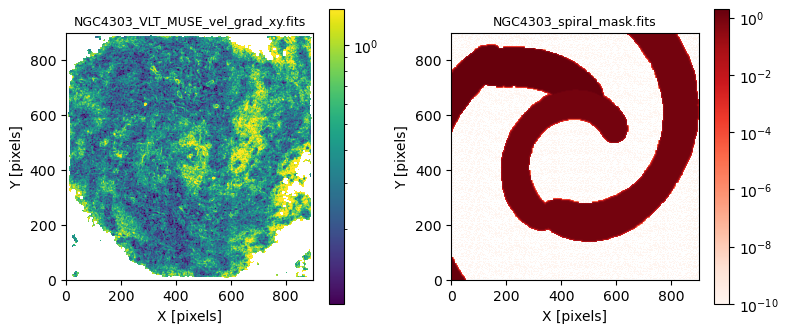

C:\Users\kpoli\AppData\Local\Temp\ipykernel_12108\3677983542.py:14: MatplotlibDeprecationWarning: Keeping empty pdf files is deprecated since 3.8 and support will be removed two minor releases later.
  with PdfPages(filename) as pdf:


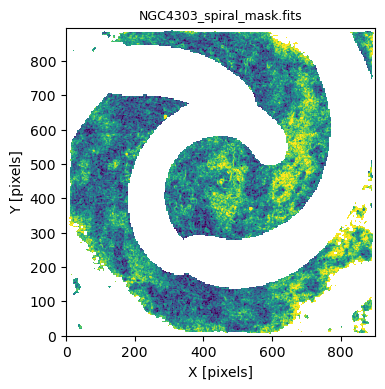

In [11]:
import importlib
import gc
from matplotlib import pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import velocity_analysis
# ПЕРЕЗАГРУЗКА МОДУЛЯ
importlib.reload(velocity_analysis)
from velocity_analysis import overlay_multiple_fits, plot_with_zoom
galaxy_name = "NGC4303"
file_ref = f"data/{galaxy_name}/{galaxy_name}_VLT_MUSE_vel_grad_xy.fits"
files = [f"data/input{galaxy_name}/{galaxy_name}_spiral_mask.fits"]
filename = f"pic/{galaxy_name}_spiral.pdf"

with PdfPages(filename) as pdf:
# Совмещаем изображения
    overlay_multiple_fits(file_ref, files, alphas=[0.9, 1], mod="mask", cmaps=["viridis", "Reds"], zoom=None, pdf=pdf, image_overlay=False, galaxy_name=galaxy_name)
    # plot_with_zoom(fits.open(file_ref)[0].data, zoom_area=zoom_area, pdf=pdf)
